>> Loading GOES-18 observational data...
>> Loading LAG-GC data...
>> Loading LAG-L data...
>> Loading SLAG-V data...
>> Generating revised GOES-18 validation figure...
>> Saved Combined_Plots/Combined_GOES18_Validation_Revised.pdf
>> Saved Combined_Plots/Combined_GOES18_Validation_Revised.png


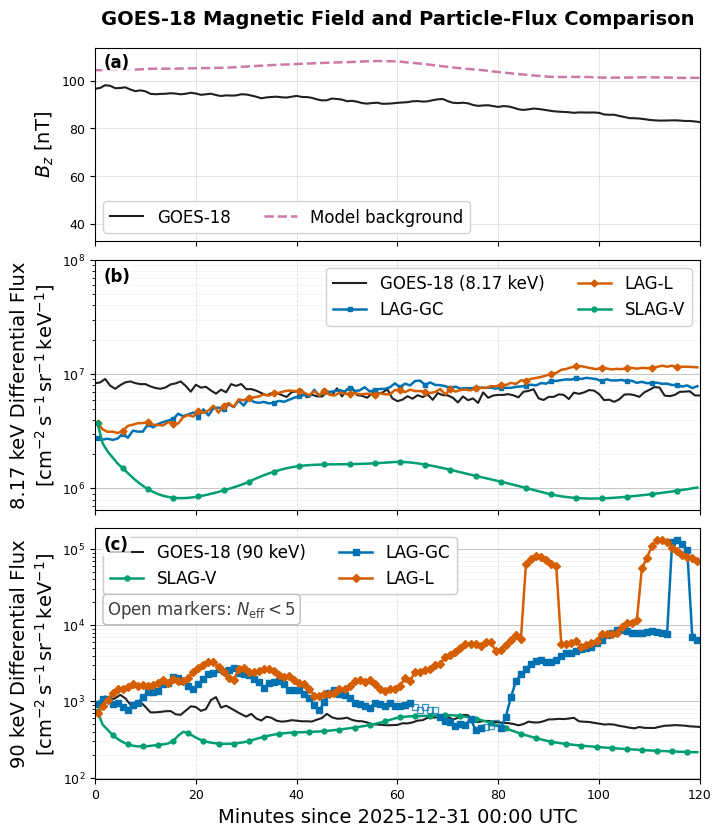

>> Generating revised density-time diagrams...
>> Saved Combined_Plots/Combined_Hovmoller_Diagnostics_Revised.pdf
>> Saved Combined_Plots/Combined_Hovmoller_Diagnostics_Revised.png


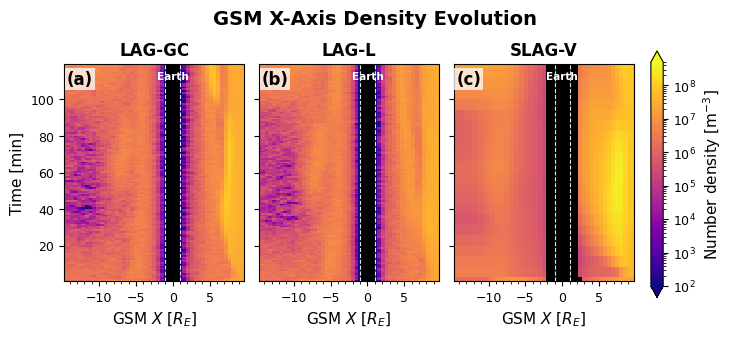

>> Generating physical particle-population figure...
>> Saved Combined_Plots/Combined_EstimatedPhysicalParticlePopulation.pdf
>> Saved Combined_Plots/Combined_EstimatedPhysicalParticlePopulation.png


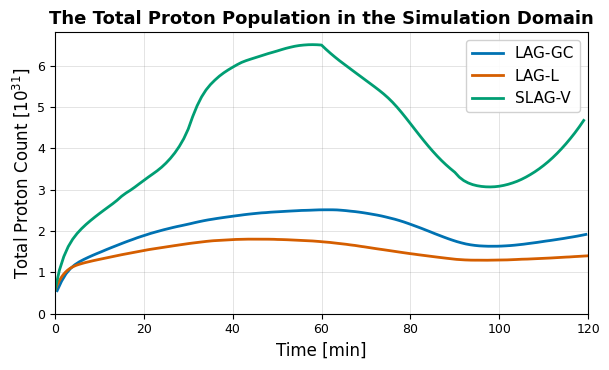

>> Generating time-sliced spectra figure...
>> Target t=0 min: LAG-GC=0.5, LAG-L=0.5, SLAG-V=0 min
>> Target t=60 min: LAG-GC=59.5, LAG-L=59.5, SLAG-V=62.8571 min
>> Target t=120 min: LAG-GC=119.5, LAG-L=119.5, SLAG-V=120 min
>> Saved Combined_Plots/Combined_GlobalSpectra_TimeSlices.pdf
>> Saved Combined_Plots/Combined_GlobalSpectra_TimeSlices.png


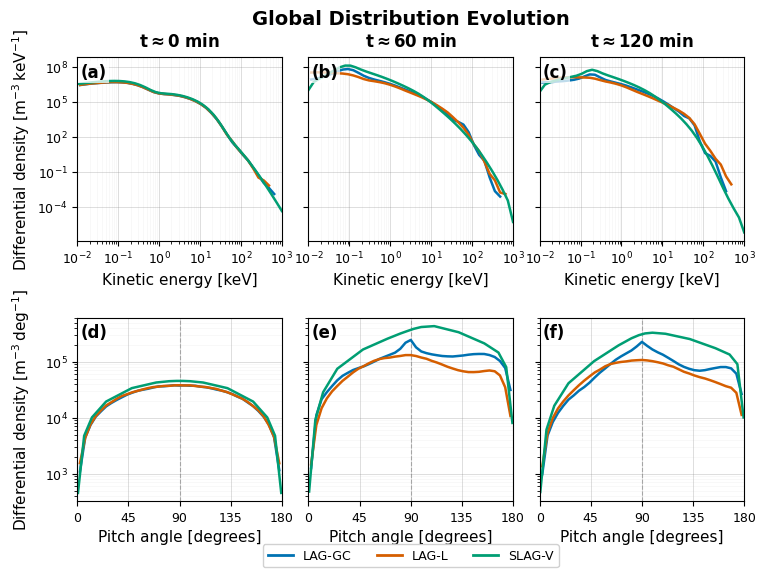

>> All revised plotting routines finished successfully.


In [ ]:
import os
import glob
import pickle
from datetime import datetime, timezone

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D


# =============================================================================
# 1. CONSTANTS AND CONFIGURATION
# =============================================================================

RE = 6.371e6
Q_E = 1.602e-19

SIM_START_TIME = datetime(
    2025, 12, 31, 0, 0, 0,
    tzinfo=timezone.utc,
)
SIM_START_UNIX = SIM_START_TIME.timestamp()

MAX_TIME_SECONDS = 7200.0
MAX_TIME_MINUTES = MAX_TIME_SECONDS / 60.0

DENS_VMIN = 1e2
DENS_VMAX = 5e8

LOW_ENERGY_KEV = 8.17
HIGH_ENERGY_KEV = 90.0


# Colorblind-friendly and consistent model colors
COLORS = {
    "GOES": "#202020",
    "LAG-GC": "#0072B2",
    "LAG-L": "#D55E00",
    "SLAG-V": "#009E73",
    "BACKGROUND": "#CC79A7",
}

MARKERS = {
    "LAG-GC": "s",
    "LAG-L": "D",
    "SLAG-V": "o",
}


plt.rcParams.update({
    "font.size": 10,
    "font.weight": "normal",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
    "axes.linewidth": 0.8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 14,
    "figure.titleweight": "bold",
    "lines.linewidth": 1.8,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Preserve editable text in PDF output.
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# =============================================================================
# 2. PATHS
# =============================================================================

goes_base_dir = "goes_data/goes18"
output_dir = "Combined_Plots"

gc_base_dir = "GIFs/GuidingCenter/LinuxRuns/1"
l_base_dir = "GIFs/FullLorentz/LinuxRuns/Final"
v_base_dir = (
    "/Users/nfurioso1/Library/CloudStorage/"
    "OneDrive-UniversityofFlorida/Research/Journal_Paper/"
    "GC_motion_in_MHD/GIFs/Distributional/LinuxRuns/Final"
)

os.makedirs(output_dir, exist_ok=True)


# =============================================================================
# 3. GENERAL HELPER FUNCTIONS
# =============================================================================

def get_latest_run(base_directory, prefix=""):
    """Return the most recently modified matching subdirectory."""
    if not os.path.exists(base_directory):
        return base_directory

    folders = [
        path
        for path in glob.glob(
            os.path.join(base_directory, prefix + "*")
        )
        if os.path.isdir(path)
    ]

    if not folders:
        return base_directory

    folders.sort(key=os.path.getmtime)
    return folders[-1]


def find_first_pickle(directory):
    """Return the first plot-data pickle file in a directory."""
    files = sorted(
        glob.glob(
            os.path.join(directory, "*_plot_data.pkl")
        )
    )

    if not files:
        raise FileNotFoundError(
            f"No '*_plot_data.pkl' file found in {directory}"
        )

    return files[0]


def save_publication_figure(fig, directory, basename):
    """Save a figure as editable PDF and high-resolution PNG."""
    pdf_path = os.path.join(directory, f"{basename}.pdf")
    png_path = os.path.join(directory, f"{basename}.png")

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")

    print(f">> Saved {pdf_path}")
    print(f">> Saved {png_path}")


def add_panel_label(ax, label):
    """Add a manuscript-style panel label."""
    ax.text(
        0.015,
        0.97,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.75,
            "pad": 1.5,
        },
        zorder=20,
    )


def positive_or_nan(values):
    """Replace nonfinite and nonpositive values with NaN."""
    values = np.asarray(values, dtype=np.float64)

    return np.where(
        np.isfinite(values) & (values > 0.0),
        values,
        np.nan,
    )


def positive_mask(values):
    """Mask nonfinite and nonpositive values."""
    values = np.asarray(values, dtype=np.float64)

    return np.ma.masked_where(
        ~np.isfinite(values) | (values <= 0.0),
        values,
    )


def nearest_index(times, target_time):
    """Return the index nearest a requested time."""
    times = np.asarray(times, dtype=np.float64)

    finite_indices = np.flatnonzero(
        np.isfinite(times)
    )

    if finite_indices.size == 0:
        raise ValueError(
            "No finite snapshot times were found."
        )

    nearest_local_index = np.argmin(
        np.abs(times[finite_indices] - target_time)
    )

    return finite_indices[nearest_local_index]


def format_log_flux_axis(ax):
    """Apply consistent logarithmic formatting to a flux axis."""
    ax.set_yscale("log")

    ax.yaxis.set_major_locator(
        ticker.LogLocator(base=10.0)
    )

    ax.yaxis.set_minor_locator(
        ticker.LogLocator(
            base=10.0,
            subs=np.arange(2, 10) * 0.1,
            numticks=100,
        )
    )

    ax.yaxis.set_minor_formatter(
        ticker.NullFormatter()
    )

    ax.grid(
        True,
        axis="y",
        which="major",
        color="0.35",
        alpha=0.35,
        linewidth=0.7,
    )

    ax.grid(
        True,
        axis="y",
        which="minor",
        color="0.65",
        alpha=0.18,
        linewidth=0.4,
    )

    ax.grid(
        True,
        axis="x",
        which="major",
        color="0.5",
        alpha=0.25,
        linestyle="--",
        linewidth=0.6,
    )


def load_model_bz(directory, filename, fallback_times):
    """Load a model Bz CSV or return NaNs if it is unavailable."""
    path = os.path.join(directory, filename)

    try:
        data = np.loadtxt(
            path,
            delimiter=",",
            skiprows=1,
        )

        return data[:, 0], data[:, 1]

    except Exception as error:
        print(
            f"WARNING: Could not load {path}: {error}"
        )

        fallback_times = np.asarray(
            fallback_times,
            dtype=np.float64,
        )

        return (
            fallback_times,
            np.full_like(
                fallback_times,
                np.nan,
                dtype=np.float64,
            ),
        )


# =============================================================================
# 4. GOES ENERGY-CHANNEL HELPERS
# =============================================================================

def get_energy_values_kev(dataset, flux_data_array, energy_dimension):
    """
    Find an energy variable associated with the flux energy dimension.

    The returned values are converted to keV when the units metadata are
    available. Additional dimensions such as detector, telescope, or bounds
    are collapsed using their median.
    """
    candidates = []

    for variable_name, variable in dataset.variables.items():
        lower_name = variable_name.lower()

        if energy_dimension not in variable.dims:
            continue

        if (
            "energy" in lower_name
            or "energies" in lower_name
            or "kev" in lower_name
            or "ev" in lower_name
        ):
            candidates.append(
                (variable_name, variable)
            )

    # Prefer an energy coordinate whose name exactly matches the dimension.
    candidates.sort(
        key=lambda item: item[0] != energy_dimension
    )

    for variable_name, variable in candidates:
        try:
            # Added a try-except block to ignore string/label variables 
            # like b'ProtonEnergyBand-1'
            values = np.asarray(
                variable.values,
                dtype=np.float64,
            )
        except (ValueError, TypeError):
            continue

        if values.size == 0:
            continue

        energy_axis = variable.dims.index(
            energy_dimension
        )

        values = np.moveaxis(
            values,
            energy_axis,
            0,
        )

        values = np.nanmedian(
            values.reshape(values.shape[0], -1),
            axis=1,
        )

        expected_size = flux_data_array.sizes[
            energy_dimension
        ]

        if values.size != expected_size:
            continue

        units = str(
            variable.attrs.get("units", "")
        ).lower()

        energies_kev = values.copy()

        if "mev" in units:
            energies_kev *= 1.0e3

        elif "kev" in units:
            pass

        elif "ev" in units:
            energies_kev /= 1.0e3

        else:
            finite_values = energies_kev[
                np.isfinite(energies_kev)
            ]

            if (
                finite_values.size > 0
                and np.nanmedian(
                    np.abs(finite_values)
                ) > 2.0e3
            ):
                energies_kev /= 1.0e3

                print(
                    "WARNING: Interpreting unlabeled energy "
                    f"variable '{variable_name}' as eV."
                )

        if np.any(np.isfinite(energies_kev)):
            print(
                f">> Using GOES energy coordinate: "
                f"{variable_name}"
            )

            return energies_kev

    return None


def extract_goes_flux_channel(
    dataset,
    flux_variable,
    target_energy_kev,
    fallback_index=None,
):
    """
    Extract the flux channel nearest a requested energy.

    Dimensions other than time and energy are reduced using nanmax so that
    the peak directional flux is retained. The selected channel is averaged
    to one-minute cadence.
    """
    if flux_variable not in dataset:
        raise KeyError(
            f"Variable '{flux_variable}' was not found. "
            f"Available data variables are: "
            f"{list(dataset.data_vars)}"
        )

    flux_data_array = dataset[flux_variable]

    # 1. Identify the time dimension (often 'report_number' in GOES L1b data)
    time_dimensions = [
        dimension
        for dimension in flux_data_array.dims
        if "time" in dimension.lower() or "report" in dimension.lower()
    ]

    if not time_dimensions:
        raise ValueError(
            f"Could not identify the time dimension of "
            f"{flux_variable}. Dimensions were "
            f"{flux_data_array.dims}."
        )

    time_dimension = time_dimensions[0]

    # 2. Inject Datetime Coordinates if Missing
    # If the dimension is an integer index, xarray cannot resample it to "1Min".
    if not np.issubdtype(flux_data_array[time_dimension].dtype, np.datetime64):
        print(f"WARNING: '{time_dimension}' lacks datetime64 coordinates. Injecting 1-sec timeline.")
        start_dt64 = np.datetime64('2025-12-31T00:00:00')
        time_coords = start_dt64 + np.arange(flux_data_array.sizes[time_dimension]) * np.timedelta64(1, 's')
        flux_data_array = flux_data_array.assign_coords({time_dimension: time_coords})

    # 3. Identify the energy dimension
    energy_dimensions = [
        dimension
        for dimension in flux_data_array.dims
        if (
            "energy" in dimension.lower()
            or "ener" in dimension.lower()
            or "channel" in dimension.lower()
        )
    ]

    if energy_dimensions:
        energy_dimension = energy_dimensions[0]
    else:
        energy_dimension = flux_data_array.dims[-1]
        print(
            f"WARNING: Assuming '{energy_dimension}' is "
            f"the energy dimension for {flux_variable}."
        )

    # 4. Reduce other dimensions (e.g., taking nanmax over 'direction' for peak flux)
    reduction_dimensions = [
        dimension
        for dimension in flux_data_array.dims
        if dimension not in (
            time_dimension,
            energy_dimension,
        )
    ]

    if reduction_dimensions:
        flux_data_array = flux_data_array.max(
            dim=reduction_dimensions,
            skipna=True,
        )

    # 5. Find the correct energy channel
    energies_kev = get_energy_values_kev(
        dataset,
        flux_data_array,
        energy_dimension,
    )

    if energies_kev is not None:
        channel_index = int(
            np.nanargmin(
                np.abs(
                    energies_kev - target_energy_kev
                )
            )
        )

        selected_energy_kev = float(
            energies_kev[channel_index]
        )

        print(
            f">> Requested {target_energy_kev:g} keV "
            f"from {flux_variable}; selected "
            f"{selected_energy_kev:g} keV "
            f"(channel {channel_index})."
        )

    else:
        if fallback_index is None:
            raise ValueError(
                f"No usable energy metadata were found for "
                f"{flux_variable}, and no fallback channel "
                "was supplied."
            )

        number_of_channels = flux_data_array.sizes[
            energy_dimension
        ]

        if not 0 <= fallback_index < number_of_channels:
            raise IndexError(
                f"Fallback channel {fallback_index} is outside "
                f"the available range 0–"
                f"{number_of_channels - 1} for "
                f"{flux_variable}."
            )

        channel_index = fallback_index
        selected_energy_kev = target_energy_kev

        print(
            f"WARNING: No usable energy metadata were found "
            f"for {flux_variable}. Using fallback channel "
            f"{fallback_index}. Verify this channel against "
            "the GOES product documentation."
        )

    # 6. Extract the channel and resample
    selected_flux = flux_data_array.isel({
        energy_dimension: channel_index
    })

    selected_flux_1min = selected_flux.resample({
        time_dimension: "1min"
    }).mean(skipna=True)

    times_unix = (
        selected_flux_1min[time_dimension]
        .values.astype("datetime64[s]")
        .astype(np.float64)
    )

    flux_values = positive_or_nan(
        selected_flux_1min.values
    )

    return (
        times_unix,
        flux_values,
        selected_energy_kev,
    )


# =============================================================================
# 5. LOAD GOES-18 OBSERVATIONAL DATA
# =============================================================================

print(">> Loading GOES-18 observational data...")

mag_file = (
    f"{goes_base_dir}/l2/data/magn-l2-avg1m/"
    "2025/12/"
    "dn_magn-l2-avg1m_g18_d20251231_v2-0-4.nc"
)

mpsh_file = (
    f"{goes_base_dir}/l2/data/mpsh-l2-avg1m/"
    "2025/12/"
    "ops_seis-l1b-mpsh_g18_d20251231_v0-0-0.nc"
)

mpsl_file = (
    f"{goes_base_dir}/l2/data/mpsl-l2-avg1m/"
    "2025/12/"
    "ops_seis-l1b-mpsl_g18_d20251231_v0-0-0.nc"
)

try:
    ds_mag = xr.open_dataset(
        mag_file,
        engine="h5netcdf",
    )

    ds_mpsh = xr.open_dataset(
        mpsh_file,
        engine="h5netcdf",
    )

    ds_mpsl = xr.open_dataset(
        mpsl_file,
        engine="h5netcdf",
    )

except Exception as error:
    raise RuntimeError(
        f"Could not load the GOES-18 files: {error}"
    ) from error


if "b_gsm" not in ds_mag:
    raise KeyError(
        "'b_gsm' was not found in the GOES magnetic-field file."
    )

obs_times_unix = (
    ds_mag["time"]
    .values.astype("datetime64[s]")
    .astype(np.float64)
)

t_sync_norm = obs_times_unix - SIM_START_UNIX
obs_bz = np.asarray(
    ds_mag["b_gsm"].values[:, 2],
    dtype=np.float64,
)


# The fallback indices are used only when energy metadata cannot be found.
# Verify these fallback values against the exact GOES product version.

obs_flux_hi_times_unix, obs_flux_hi, obs_hi_energy = (
    extract_goes_flux_channel(
        dataset=ds_mpsh,
        flux_variable="DiffProtonFluxes",
        target_energy_kev=HIGH_ENERGY_KEV,
        fallback_index=0,
    )
)

obs_flux_lo_times_unix, obs_flux_lo, obs_lo_energy = (
    extract_goes_flux_channel(
        dataset=ds_mpsl,
        flux_variable="DiffIonFluxes",
        target_energy_kev=LOW_ENERGY_KEV,
        fallback_index=11,
    )
)


# =============================================================================
# 6. SIMULATION-DATA HELPERS
# =============================================================================

def get_tracker_peak_flux_split(data):
    """
    Separate reliable and low-Neff 90-keV flux estimates.

    This assumes goes_snap_flux_90keV_peak is populated only when the
    reliability criterion is satisfied.
    """
    snapshot_times = np.asarray(
        data.get("snapshot_times", []),
        dtype=np.float64,
    )

    flux_peak = np.asarray(
        data.get(
            "goes_snap_flux_90keV_peak",
            np.full(
                len(snapshot_times),
                np.nan,
                dtype=np.float64,
            ),
        ),
        dtype=np.float64,
    )

    reliable_mask = (
        np.isfinite(flux_peak)
        & (flux_peak > 0.0)
    )

    reliable_flux = flux_peak.copy()
    reliable_flux[~reliable_mask] = np.nan

    neff_by_source = data.get(
        "goes_neff_90_by_source"
    )

    flux_by_source = data.get(
        "goes_flux_90_by_source"
    )

    if (
        neff_by_source is not None
        and flux_by_source is not None
    ):
        neff_by_source = np.asarray(
            neff_by_source,
            dtype=np.float64,
        )

        flux_by_source = np.asarray(
            flux_by_source,
            dtype=np.float64,
        )

        safe_neff = np.where(
            np.isfinite(neff_by_source),
            neff_by_source,
            -np.inf,
        )

        best_source_index = np.argmax(
            safe_neff,
            axis=1,
        )

        fallback_flux = np.take_along_axis(
            flux_by_source,
            best_source_index[:, None],
            axis=1,
        ).squeeze(axis=1)

    else:
        fallback_flux = np.asarray(
            data.get(
                "goes_1min_flux_90_all_sources",
                np.full_like(
                    flux_peak,
                    np.nan,
                    dtype=np.float64,
                ),
            ),
            dtype=np.float64,
        )

    unreliable_flux = fallback_flux.copy()
    unreliable_flux[reliable_mask] = np.nan

    unreliable_flux[
        ~np.isfinite(unreliable_flux)
        | (unreliable_flux <= 0.0)
    ] = np.nan

    return reliable_flux, unreliable_flux


# =============================================================================
# 7. LOAD LAG-GC DATA
# =============================================================================

print(">> Loading LAG-GC data...")

gc_run = gc_base_dir
gc_pickle = find_first_pickle(gc_run)

with open(gc_pickle, "rb") as file:
    gc_data = pickle.load(file)

gc_t_min = (
    np.asarray(
        gc_data["snapshot_times"],
        dtype=np.float64,
    )
    / 60.0
)

gc_bz_t, gc_bz = load_model_bz(
    gc_run,
    "model_C_bz.csv",
    gc_t_min,
)

# Confirm that this stored proxy corresponds to the intended 8.17-keV
# comparison channel.
gc_flux_8_peak = positive_or_nan(
    gc_data.get(
        "goes_snap_flux_10keV_peak",
        np.full(
            len(gc_t_min),
            np.nan,
            dtype=np.float64,
        ),
    )
)

(
    gc_flux_90_peak_rel,
    gc_flux_90_peak_unrel,
) = get_tracker_peak_flux_split(gc_data)

gc_flux_90_peak_rel = positive_or_nan(
    gc_flux_90_peak_rel
)

gc_flux_90_peak_unrel = positive_or_nan(
    gc_flux_90_peak_unrel
)

gc_tot_ptcls = np.asarray(
    gc_data.get(
        "total_physical_particles",
        np.full(
            len(gc_t_min),
            np.nan,
            dtype=np.float64,
        ),
    ),
    dtype=np.float64,
)

gc_y_centers = (
    np.asarray(gc_data["dens_y_edges"][:-1])
    + np.asarray(gc_data["dens_y_edges"][1:])
) / 2.0

y_mid_gc = np.argmin(
    np.abs(gc_y_centers)
)

gc_hov = np.asarray(
    [
        snapshot["density"][:, y_mid_gc]
        for snapshot in gc_data["density_snapshots"]
    ],
    dtype=np.float64,
)


# =============================================================================
# 8. LOAD LAG-L DATA
# =============================================================================

print(">> Loading LAG-L data...")

l_run = get_latest_run(
    l_base_dir,
    prefix="Run_",
)

l_pickle = find_first_pickle(l_run)

with open(l_pickle, "rb") as file:
    l_data = pickle.load(file)

l_t_min = (
    np.asarray(
        l_data["snapshot_times"],
        dtype=np.float64,
    )
    / 60.0
)

l_bz_t, l_bz = load_model_bz(
    l_run,
    "model_B_bz.csv",
    l_t_min,
)

# Confirm that this stored proxy corresponds to the intended 8.17-keV
# comparison channel.
l_flux_8_peak = positive_or_nan(
    l_data.get(
        "goes_snap_flux_10keV_peak",
        np.full(
            len(l_t_min),
            np.nan,
            dtype=np.float64,
        ),
    )
)

(
    l_flux_90_peak_rel,
    l_flux_90_peak_unrel,
) = get_tracker_peak_flux_split(l_data)

l_flux_90_peak_rel = positive_or_nan(
    l_flux_90_peak_rel
)

l_flux_90_peak_unrel = positive_or_nan(
    l_flux_90_peak_unrel
)

l_tot_ptcls = np.asarray(
    l_data.get(
        "global_mass_history",
        [],
    ),
    dtype=np.float64,
)

l_tot_t = (
    np.asarray(
        l_data.get(
            "global_time_history",
            [],
        ),
        dtype=np.float64,
    )
    / 60.0
)

l_y_centers = (
    np.asarray(l_data["dens_y_edges"][:-1])
    + np.asarray(l_data["dens_y_edges"][1:])
) / 2.0

y_mid_l = np.argmin(
    np.abs(l_y_centers)
)

l_hov = np.asarray(
    [
        snapshot["density"][:, y_mid_l]
        for snapshot in l_data["density_snapshots"]
    ],
    dtype=np.float64,
)


# =============================================================================
# 9. LOAD SLAG-V DATA
# =============================================================================

print(">> Loading SLAG-V data...")

v_run = v_base_dir
v_pickle = find_first_pickle(v_run)

with open(v_pickle, "rb") as file:
    v_data = pickle.load(file)

v_sim_data = v_data["sim_data"]

v_t_min = np.asarray(
    [
        snapshot["time"] / 60.0
        for snapshot in v_sim_data
    ],
    dtype=np.float64,
)

v_bz_t, v_bz = load_model_bz(
    v_run,
    "model_A_bz.csv",
    v_t_min,
)

v_flux_path = os.path.join(
    v_run,
    "model_A_vlasov_fluxes.csv",
)

v_flux_table = np.genfromtxt(
    v_flux_path,
    delimiter=",",
    names=True,
)

v_flux_t_min = np.asarray(
    v_flux_table["time_min"],
    dtype=np.float64,
)

v_flux_8_peak = positive_or_nan(
    v_flux_table[
        "flux_8p17keV_proxy_peak_directional_all_sources"
    ]
)

v_flux_90_peak = positive_or_nan(
    v_flux_table[
        "flux_90keV_proxy_peak_directional_all_sources"
    ]
)

v_tot_ptcls = np.asarray(
    v_data["mass_values"],
    dtype=np.float64,
)

v_tot_t = (
    np.asarray(
        v_data["mass_times"],
        dtype=np.float64,
    )
    / 60.0
)

v_hov = np.asarray(
    [
        snapshot["x_slice"]
        for snapshot in v_sim_data
    ],
    dtype=np.float64,
)


# =============================================================================
# 10. GOES-18 VALIDATION FIGURE
# =============================================================================

print(">> Generating revised GOES-18 validation figure...")

fig_validation, validation_axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(7.2, 8.5),
    sharex=True,
    gridspec_kw={
        "height_ratios": [0.85, 1.1, 1.1],
        "hspace": 0.08,
    },
)

ax_bz = validation_axes[0]
ax_flux_low = validation_axes[1]
ax_flux_high = validation_axes[2]


# -----------------------------------------------------------------------------
# Panel (a): Bz
# -----------------------------------------------------------------------------

ax_bz.plot(
    t_sync_norm / 60.0,
    obs_bz,
    color=COLORS["GOES"],
    linewidth=1.5,
    label="GOES-18",
)

ax_bz.plot(
    v_bz_t,
    v_bz,
    color=COLORS["BACKGROUND"],
    linestyle="--",
    linewidth=1.8,
    label="Model background",
)

# Tighten the Bz panel dynamically
finite_bz = np.concatenate([
    np.asarray(obs_bz, dtype=float).ravel(),
    np.asarray(v_bz, dtype=float).ravel(),
])
finite_bz = finite_bz[np.isfinite(finite_bz)]

if finite_bz.size:
    bz_min = np.nanmin(finite_bz)
    bz_max = np.nanmax(finite_bz)
    bz_padding = max(1.0, 0.08 * (bz_max - bz_min))
    ax_bz.set_ylim(
        bz_min - bz_padding,
        bz_max + bz_padding,
    )

ax_bz.set_ylabel(r"$B_z$ [nT]", fontsize=14)

ax_bz.grid(
    True,
    which="major",
    color="0.5",
    alpha=0.25,
    linewidth=0.6,
)

ax_bz.legend(
    loc="best",
    ncol=2,
    frameon=True,
    framealpha=0.9,
    fontsize=12  # <-- Add this line
)

add_panel_label(ax_bz, "(a)")


# -----------------------------------------------------------------------------
# Panel (b): low-energy flux
# -----------------------------------------------------------------------------

ax_flux_low.plot(
    (
        obs_flux_lo_times_unix
        - SIM_START_UNIX
    ) / 60.0,
    obs_flux_lo,
    color=COLORS["GOES"],
    linewidth=1.5,
    label=f"GOES-18 ({obs_lo_energy:g} keV)",
)

ax_flux_low.plot(
    gc_t_min,
    gc_flux_8_peak,
    color=COLORS["LAG-GC"],
    marker=MARKERS["LAG-GC"],
    markersize=3.5,
    markevery=5,
    label="LAG-GC",
)

ax_flux_low.plot(
    l_t_min,
    l_flux_8_peak,
    color=COLORS["LAG-L"],
    marker=MARKERS["LAG-L"],
    markersize=3.5,
    markevery=5,
    label="LAG-L",
)

ax_flux_low.plot(
    v_flux_t_min,
    v_flux_8_peak,
    color=COLORS["SLAG-V"],
    marker=MARKERS["SLAG-V"],
    markersize=3.5,
    markevery=5,
    label="SLAG-V",
)

ax_flux_low.set_ylabel(
    "8.17 keV Differential Flux\n"
    r"[$\mathrm{cm^{-2}\,s^{-1}\,sr^{-1}\,keV^{-1}}$]", fontsize=14
)

format_log_flux_axis(ax_flux_low)

ax_flux_low.legend(
    loc="best",
    ncol=2,
    frameon=True,
    framealpha=0.9,
    fontsize=12  # <-- Add this line
)

add_panel_label(ax_flux_low, "(b)")


# -----------------------------------------------------------------------------
# Panel (c): high-energy flux
# -----------------------------------------------------------------------------

ax_flux_high.plot(
    (
        obs_flux_hi_times_unix
        - SIM_START_UNIX
    ) / 60.0,
    obs_flux_hi,
    color=COLORS["GOES"],
    linewidth=1.5,
    label=f"GOES-18 ({obs_hi_energy:g} keV)",
)

ax_flux_high.plot(
    v_flux_t_min,
    v_flux_90_peak,
    color=COLORS["SLAG-V"],
    marker=MARKERS["SLAG-V"],
    markersize=3.5,
    markevery=3,
    label="SLAG-V",
)

# Reliable LAG-GC values
ax_flux_high.plot(
    gc_t_min,
    gc_flux_90_peak_rel,
    color=COLORS["LAG-GC"],
    marker=MARKERS["LAG-GC"],
    markersize=4.0,
    markerfacecolor=COLORS["LAG-GC"],
    markeredgecolor=COLORS["LAG-GC"],
    label="LAG-GC",
)

# Low-Neff LAG-GC values
ax_flux_high.plot(
    gc_t_min,
    gc_flux_90_peak_unrel,
    linestyle="none",
    color=COLORS["LAG-GC"],
    marker=MARKERS["LAG-GC"],
    markersize=4.5,
    markerfacecolor="none",
    markeredgecolor=COLORS["LAG-GC"],
    markeredgewidth=0.9,
    alpha=0.75,
)

# Reliable LAG-L values
ax_flux_high.plot(
    l_t_min,
    l_flux_90_peak_rel,
    color=COLORS["LAG-L"],
    marker=MARKERS["LAG-L"],
    markersize=4.0,
    markerfacecolor=COLORS["LAG-L"],
    markeredgecolor=COLORS["LAG-L"],
    label="LAG-L",
)

# Low-Neff LAG-L values
ax_flux_high.plot(
    l_t_min,
    l_flux_90_peak_unrel,
    linestyle="none",
    color=COLORS["LAG-L"],
    marker=MARKERS["LAG-L"],
    markersize=4.5,
    markerfacecolor="none",
    markeredgecolor=COLORS["LAG-L"],
    markeredgewidth=0.9,
    alpha=0.75,
)

ax_flux_high.set_ylabel(
    "90 keV Differential Flux\n"
    r"[$\mathrm{cm^{-2}\,s^{-1}\,sr^{-1}\,keV^{-1}}$]", fontsize=14
)

ax_flux_high.set_xlabel(
    "Time [min]", fontsize=14
)

format_log_flux_axis(ax_flux_high)

model_legend = ax_flux_high.legend(
    loc="upper left",
    ncol=2,
    frameon=True,
    framealpha=0.9,
    fontsize=12,
)

ax_flux_high.add_artist(model_legend)

# Replace the large confidence legend with a compact annotation positioned below the legend
ax_flux_high.text(
    0.02,          # x-position aligned with the left side of the legend
    0.72,          # y-position placed just below the upper-left legend box
    r"Open markers: $N_{\mathrm{eff}}<5$",
    transform=ax_flux_high.transAxes,
    ha="left",
    va="top",      # anchor the top of the text box to this y coordinate
    fontsize=12,
    color="0.25",
    bbox={
        "facecolor": "white",
        "edgecolor": "0.75",
        "alpha": 1.0,
        "boxstyle": "round,pad=0.25",
    },
    zorder=20,
)

add_panel_label(ax_flux_high, "(c)")

for axis in validation_axes:
    axis.set_xlim(
        0.0,
        MAX_TIME_MINUTES,
    )

fig_validation.suptitle(
    "GOES-18 Magnetic Field and Particle-Flux Comparison",
    x=0.56,  # <-- Centers the title with the subplots/x-axis
    y=0.995,
)

fig_validation.subplots_adjust(
    left=0.14,
    right=0.98,
    bottom=0.09,
    top=0.95,
)

save_publication_figure(
    fig_validation,
    output_dir,
    "Combined_GOES18_Validation_Revised",
)

plt.show(block=False)


# =============================================================================
# 11. DENSITY–TIME DIAGRAMS
# =============================================================================

print(">> Generating revised density-time diagrams...")

x_centers_gc = (
    (
        np.asarray(gc_data["dens_x_edges"][:-1])
        + np.asarray(gc_data["dens_x_edges"][1:])
    )
    / 2.0
    / RE
)

x_centers_l = (
    (
        np.asarray(l_data["dens_x_edges"][:-1])
        + np.asarray(l_data["dens_x_edges"][1:])
    )
    / 2.0
    / RE
)

x_centers_v = (
    np.asarray(
        v_data["sim_x"],
        dtype=np.float64,
    )
    / RE
)

# Use the overlapping domain to facilitate direct comparison.
common_x_min = max(
    np.nanmin(x_centers_gc),
    np.nanmin(x_centers_l),
    np.nanmin(x_centers_v),
)

common_x_max = min(
    np.nanmax(x_centers_gc),
    np.nanmax(x_centers_l),
    np.nanmax(x_centers_v),
)

common_t_min = max(
    np.nanmin(gc_t_min),
    np.nanmin(l_t_min),
    np.nanmin(v_t_min),
)

common_t_max = min(
    np.nanmax(gc_t_min),
    np.nanmax(l_t_min),
    np.nanmax(v_t_min),
    MAX_TIME_MINUTES,
)

fig_hov, hov_axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(7.4, 3.2),
    sharex=True,
    sharey=True,
    gridspec_kw={
        "wspace": 0.08,
    },
)

density_norm = LogNorm(
    vmin=DENS_VMIN,
    vmax=DENS_VMAX,
)

# Standard colormap for LAG-GC and LAG-L (missing values mapped to gray)
density_cmap = plt.colormaps["plasma"].copy()
density_cmap.set_bad("#D9D9D9")

# Dedicated colormap for SLAG-V (missing/inner values mapped to black)
density_cmap_v = plt.colormaps["plasma"].copy()
density_cmap_v.set_bad("#000000")

hovmoller_specifications = [
    (
        hov_axes[0],
        x_centers_gc,
        gc_t_min,
        gc_hov,
        "LAG-GC",
        "(a)",
    ),
    (
        hov_axes[1],
        x_centers_l,
        l_t_min,
        l_hov,
        "LAG-L",
        "(b)",
    ),
    (
        hov_axes[2],
        x_centers_v,
        v_t_min,
        v_hov,
        "SLAG-V",
        "(c)",
    ),
]

hovmoller_images = []

for (
    axis,
    x_values,
    time_values,
    density_values,
    title,
    panel_label,
) in hovmoller_specifications:

    # Prepare masked data array
    masked_data = positive_mask(density_values)

    # For SLAG-V, mask out the region within 2 R_E so it renders as black
    if title == "SLAG-V":
        current_cmap = density_cmap_v
        inner_mask = (x_values >= -2.0) & (x_values <= 2.0)
        masked_data.mask = masked_data.mask | inner_mask[None, :]
    else:
        current_cmap = density_cmap

    image = axis.pcolormesh(
        x_values,
        time_values,
        masked_data,
        shading="auto",
        cmap=current_cmap,
        norm=density_norm,
        rasterized=True,
    )

    hovmoller_images.append(image)

    # Completely fill the Earth region (-1 RE <= X <= 1 RE) with a solid color
    axis.axvspan(
        -1.0,
        1.0,
        facecolor="black",
        edgecolor="none",
        alpha=1.0,
        zorder=5,
    )

    axis.axvline(
        -1.0,
        color="white",
        linestyle="--",
        linewidth=0.8,
        alpha=0.9,
        zorder=6,
    )

    axis.axvline(
        1.0,
        color="white",
        linestyle="--",
        linewidth=0.8,
        alpha=0.9,
        zorder=6,
    )

    axis.text(
        0.0,
        common_t_max
        - 0.035 * (
            common_t_max - common_t_min
        ),
        "Earth",
        color="1",
        fontsize=7.5,
        ha="center",
        va="top",
        fontweight="bold",
        zorder=7,
    )

    axis.set_title(title)
    axis.set_xlabel(r"GSM $X$ [$R_E$]")

    axis.set_xlim(
        common_x_min,
        common_x_max,
    )

    axis.xaxis.set_major_locator(ticker.MultipleLocator(5.0))
    axis.xaxis.set_minor_locator(ticker.MultipleLocator(1.0))

    axis.set_ylim(
        common_t_min,
        common_t_max,
    )

    add_panel_label(
        axis,
        panel_label,
    )

hov_axes[0].set_ylabel("Time [min]")

colorbar = fig_hov.colorbar(
    hovmoller_images[0],
    ax=hov_axes,
    pad=0.05,
    fraction=0.035,
    extend="both",
)

colorbar.set_label(
    r"Number Density [$\mathrm{m^{-3}}$]"
)

fig_hov.suptitle(
    "GSM X-Axis Density Evolution",
    y=1.01,
)

fig_hov.subplots_adjust(
    left=0.08,
    right=0.85,
    bottom=0.16,
    top=0.84,
)

save_publication_figure(
    fig_hov,
    output_dir,
    "Combined_Hovmoller_Diagnostics_Revised",
)

plt.show(block=False)


# =============================================================================
# 12. PHYSICAL PARTICLE POPULATIONS
# =============================================================================

print(">> Generating physical particle-population figure...")

def validate_particle_series(times, values, model_name):
    """Validate and filter a physical-particle time series."""
    times = np.asarray(times, dtype=np.float64)
    values = np.asarray(values, dtype=np.float64)

    if times.size != values.size:
        raise ValueError(
            f"{model_name}: time array has {times.size} values, "
            f"but particle array has {values.size} values."
        )

    valid = (
        np.isfinite(times)
        & np.isfinite(values)
        & (values >= 0.0)
    )

    if not np.any(valid):
        raise ValueError(
            f"{model_name}: no finite nonnegative particle totals found."
        )

    return times[valid], values[valid]


gc_particle_t, gc_particle_n = validate_particle_series(
    gc_t_min,
    gc_tot_ptcls,
    "LAG-GC",
)

l_particle_t, l_particle_n = validate_particle_series(
    l_tot_t,
    l_tot_ptcls,
    "LAG-L",
)

v_particle_t, v_particle_n = validate_particle_series(
    v_tot_t,
    v_tot_ptcls,
    "SLAG-V",
)


# Display values in convenient physical units while retaining the actual
# estimated physical particle totals.
PARTICLE_SCALE = 1.0e31

fig_population, ax_population = plt.subplots(
    figsize=(6.2, 3.8)
)

ax_population.plot(
    gc_particle_t,
    gc_particle_n / PARTICLE_SCALE,
    color=COLORS["LAG-GC"],
    linewidth=2.0,
    label="LAG-GC",
)

ax_population.plot(
    l_particle_t,
    l_particle_n / PARTICLE_SCALE,
    color=COLORS["LAG-L"],
    linewidth=2.0,
    label="LAG-L",
)

ax_population.plot(
    v_particle_t,
    v_particle_n / PARTICLE_SCALE,
    color=COLORS["SLAG-V"],
    linewidth=2.0,
    label="SLAG-V",
)

ax_population.set_xlim(
    0.0,
    MAX_TIME_MINUTES,
)

ax_population.set_ylim(bottom=0.0)

# Increased font sizes for axis labels and title
ax_population.set_xlabel("Time [min]", fontsize=12)
ax_population.set_ylabel(
    r"Total Proton Count [$10^{31}$]", fontsize=12
)
ax_population.set_title(
    "The Total Proton Population in the Simulation Domain",
    fontsize=13,
    fontweight="bold",
)

ax_population.grid(
    True,
    which="major",
    color="0.5",
    alpha=0.25,
    linewidth=0.6,
)

ax_population.legend(
    loc="upper right",
    ncol=1,
    frameon=True,
    framealpha=0.9,
    fontsize=11,  # Increased legend font size
)

fig_population.tight_layout()

save_publication_figure(
    fig_population,
    output_dir,
    "Combined_EstimatedPhysicalParticlePopulation",
)

plt.show(block=False)


# =============================================================================
# 13. TIME-SLICED ENERGY AND PITCH-ANGLE SPECTRA
# =============================================================================

print(">> Generating time-sliced spectra figure...")

target_times_min = np.array(
    [
        0.0,
        MAX_TIME_MINUTES / 2.0,
        MAX_TIME_MINUTES,
    ],
    dtype=np.float64,
)

v_energy_axis = (
    np.asarray(
        v_data["sim_Ek"],
        dtype=np.float64,
    )
    / (1000.0 * Q_E)
)

v_pitch_axis = np.degrees(
    np.asarray(
        v_data["sim_alpha"],
        dtype=np.float64,
    )
)

gc_energy_axis = (
    np.asarray(
        gc_data["e_bins"][:-1],
        dtype=np.float64,
    )
    + np.asarray(
        gc_data["e_bins"][1:],
        dtype=np.float64,
    )
) / 2.0

gc_pitch_axis = (
    np.asarray(
        gc_data["alpha_bins"][:-1],
        dtype=np.float64,
    )
    + np.asarray(
        gc_data["alpha_bins"][1:],
        dtype=np.float64,
    )
) / 2.0

l_energy_axis = (
    np.asarray(
        l_data["e_bins"][:-1],
        dtype=np.float64,
    )
    + np.asarray(
        l_data["e_bins"][1:],
        dtype=np.float64,
    )
) / 2.0

l_pitch_axis = (
    np.asarray(
        l_data["alpha_bins"][:-1],
        dtype=np.float64,
    )
    + np.asarray(
        l_data["alpha_bins"][1:],
        dtype=np.float64,
    )
) / 2.0

fig_spectra, spectra_axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(7.8, 6.0),
    sharex="row",
    sharey="row",
    gridspec_kw={
        "hspace": 0.42,
        "wspace": 0.13,  # <-- INCREASED from 0.10 to add space between columns
    },
)

panel_labels = [
    ["(a)", "(b)", "(c)"],
    ["(d)", "(e)", "(f)"],
]

for column_index, target_time in enumerate(
    target_times_min
):
    ax_energy = spectra_axes[0, column_index]
    ax_pitch = spectra_axes[1, column_index]

    gc_index = nearest_index(
        gc_t_min,
        target_time,
    )

    l_index = nearest_index(
        l_t_min,
        target_time,
    )

    v_index = nearest_index(
        v_t_min,
        target_time,
    )

    actual_gc_time = gc_t_min[gc_index]
    actual_l_time = l_t_min[l_index]
    actual_v_time = v_t_min[v_index]

    print(
        f">> Target t={target_time:g} min: "
        f"LAG-GC={actual_gc_time:g}, "
        f"LAG-L={actual_l_time:g}, "
        f"SLAG-V={actual_v_time:g} min"
    )

    # -------------------------------------------------------------------------
    # Energy spectra
    # -------------------------------------------------------------------------

    ax_energy.plot(
        gc_energy_axis,
        positive_mask(
            gc_data["energy_spectra"][gc_index]
        ),
        color=COLORS["LAG-GC"],
        label="LAG-GC",
    )

    ax_energy.plot(
        l_energy_axis,
        positive_mask(
            l_data["energy_spectra"][l_index]
        ),
        color=COLORS["LAG-L"],
        label="LAG-L",
    )

    ax_energy.plot(
        v_energy_axis,
        positive_mask(
            v_sim_data[v_index]["spec_E"]
        ),
        color=COLORS["SLAG-V"],
        label="SLAG-V",
    )

    ax_energy.set_xscale("log")
    ax_energy.set_yscale("log")

    ax_energy.set_xlim(
        1.0e-2,
        1.0e3,
    )

    # Fully bold title implementation
    ax_energy.set_title(
        rf"$\mathbf{{t \approx {target_time:g}\ min}}$",
        pad=8,
    )

    ax_energy.grid(
        True,
        which="major",
        color="0.5",
        alpha=0.30,
        linewidth=0.6,
    )

    ax_energy.grid(
        True,
        which="minor",
        color="0.7",
        alpha=0.15,
        linewidth=0.4,
    )

    add_panel_label(
        ax_energy,
        panel_labels[0][column_index],
    )

    # -------------------------------------------------------------------------
    # Pitch-angle spectra
    # -------------------------------------------------------------------------

    ax_pitch.axvline(
        90.0,
        color="0.45",
        linestyle="--",
        linewidth=0.8,
        alpha=0.55,
        zorder=0,
    )

    ax_pitch.plot(
        gc_pitch_axis,
        positive_mask(
            gc_data["pitch_spectra"][gc_index]
        ),
        color=COLORS["LAG-GC"],
        label="LAG-GC",
    )

    ax_pitch.plot(
        l_pitch_axis,
        positive_mask(
            l_data["pitch_spectra"][l_index]
        ),
        color=COLORS["LAG-L"],
        label="LAG-L",
    )

    ax_pitch.plot(
        v_pitch_axis,
        positive_mask(
            v_sim_data[v_index]["spec_alpha"]
        ),
        color=COLORS["SLAG-V"],
        label="SLAG-V",
    )

    ax_pitch.set_yscale("log")

    ax_pitch.set_xlim(
        0.0,
        180.0,
    )

    ax_pitch.set_xticks(
        [0, 45, 90, 135, 180]
    )

    ax_pitch.grid(
        True,
        which="major",
        color="0.5",
        alpha=0.30,
        linewidth=0.6,
    )

    ax_pitch.grid(
        True,
        which="minor",
        color="0.7",
        alpha=0.15,
        linewidth=0.4,
    )

    add_panel_label(
        ax_pitch,
        panel_labels[1][column_index],
    )


# ... (existing code for setting up the plots)

spectra_axes[0, 0].set_ylabel(
    r"Differential Density "
    r"[$\mathrm{m^{-3}\,keV^{-1}}$]"
)

spectra_axes[1, 0].set_ylabel(
    r"Differential Density "
    r"[$\mathrm{m^{-3}\,deg^{-1}}$]"
)

# <-- ADD THIS LINE to perfectly align the y-axis labels vertically
fig_spectra.align_ylabels(spectra_axes[:, 0])

for axis in spectra_axes[0, :]:
    axis.set_xlabel(
        "Kinetic Energy [keV]"
    )

for axis in spectra_axes[1, :]:
    axis.set_xlabel(
        "Pitch Angle [deg]"
    )

shared_model_handles = [
    Line2D(
        [0],
        [0],
        color=COLORS["LAG-GC"],
        linewidth=2.0,
        label="LAG-GC",
    ),
    Line2D(
        [0],
        [0],
        color=COLORS["LAG-L"],
        linewidth=2.0,
        label="LAG-L",
    ),
    Line2D(
        [0],
        [0],
        color=COLORS["SLAG-V"],
        linewidth=2.0,
        label="SLAG-V",
    ),
]

fig_spectra.legend(
    handles=shared_model_handles,
    loc="lower center",
    bbox_to_anchor=(0.5575, 0.02),
    ncol=3,
    frameon=True,
    framealpha=0.9,
)

fig_spectra.suptitle(
    "Global Distribution Evolution",
    x=0.5575,
    y=0.96,
)

fig_spectra.subplots_adjust(
    left=0.13,
    right=0.985,
    bottom=0.14,                    # <-- REDUCED from 0.18 to pull the plots down closer to the legend
    top=0.88,
)

save_publication_figure(
    fig_spectra,
    output_dir,
    "Combined_GlobalSpectra_TimeSlices",
)

plt.show()

print(">> All revised plotting routines finished successfully.")


# =============================================================================
# 14. CLOSE DATASETS
# =============================================================================

ds_mag.close()
ds_mpsh.close()
ds_mpsl.close()